# EDA — NBA GOAT Analysis
**The Greatest Athlete of All Time · Exploratory Analysis Series**

---

## Purpose

This notebook analyzes **season-level and career-level performance profiles** of NBA players using historical statistics from 1950 to 2017.

Core question: **Can we quantify individual greatness across eras, positions, and playstyles into a single, defensible GOAT score?**

The scoring system rewards peak dominance, career volume, efficiency, and achievement through a four-layer composite score. This notebook validates the key design decisions behind that architecture.

---

## Data Source

```
data/raw/nba_seasons_stats_raw.csv
data/raw/nba_player_info_raw.csv
data/raw/nba_player_data_raw.csv
```

- **~4,500 unique players**, NBA season data from 1950 to 2017
- Each row in `nba_seasons_stats_raw` represents a player's single-season stats
- Raw source: Basketball-Reference via Kaggle ("NBA Players Stats since 1950")
- Advanced metrics (BPM, VORP, WS, WS/48, PER, TS%) pre-computed by Basketball-Reference

---

## Columns Used (Key)

| Column | Description |
|---|---|
| `BPM` | Box Plus/Minus — net points per 100 possessions vs average player |
| `VORP` | Value Over Replacement Player — season total value above replacement |
| `WS` | Win Shares — total wins contributed |
| `WS/48` | Win Shares per 48 minutes — efficiency metric |
| `PER` | Player Efficiency Rating — per-minute production |
| `TS%` | True Shooting % — shooting efficiency across FG, 3P, FT |
| `USG%` | Usage Rate — % of team plays used while on court |
| `Year` | Season year (1950–2017) |
| `Tm` | Team code — `TOT` flags multi-team seasons |

---

## Analysis Flow

```
1.  Dataset Overview
2.  TOT Row Problem
3.  Era Null Analysis
4.  Metric Distributions
5.  Scoring Inflation & Era Normalization
6.  Peak vs Career Analysis
7.  Correlation Matrix
8.  Min Games Threshold
9.  Achievement Join Check
10. Pre-Advanced Era Feasibility
```

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

RAW = '../../data/raw/'

In [6]:
seasons = pd.read_csv(RAW + 'nba_seasons_stats_raw.csv', low_memory=False)
player_info = pd.read_csv(RAW + 'nba_player_info_raw.csv')
player_data = pd.read_csv(RAW + 'nba_player_data_raw.csv')

print(f'seasons      : {seasons.shape[0]:,} line × {seasons.shape[1]} column')
print(f'player_info  : {player_info.shape[0]:,} line × {player_info.shape[1]} column')
print(f'player_data  : {player_data.shape[0]:,} line × {player_data.shape[1]} column')

seasons      : 24,691 line × 53 column
player_info  : 3,922 line × 8 column
player_data  : 4,550 line × 8 column


In [7]:
print('Columns:')
print(list(seasons.columns))

Columns:
['Unnamed: 0', 'Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'blanl', 'OWS', 'DWS', 'WS', 'WS/48', 'blank2', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']


In [8]:
seasons.head(5)

,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,blanl,OWS,DWS,WS,WS/48,blank2,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.00,Curly Armstrong,G-F,31.00,FTW,63.00,NaN,NaN,NaN,0.37,NaN,0.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.10,3.60,3.50,NaN,NaN,NaN,NaN,NaN,NaN,144.00,516.00,0.28,NaN,NaN,NaN,144.00,516.00,0.28,0.28,170.00,241.00,0.70,NaN,NaN,NaN,176.00,NaN,NaN,NaN,217.00,458.00
1,1,1950.00,Cliff Barker,SG,29.00,INO,49.00,NaN,NaN,NaN,0.43,NaN,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.60,0.60,2.20,NaN,NaN,NaN,NaN,NaN,NaN,102.00,274.00,0.37,NaN,NaN,NaN,102.00,274.00,0.37,0.37,75.00,106.00,0.71,NaN,NaN,NaN,109.00,NaN,NaN,NaN,99.00,279.00
2,2,1950.00,Leo Barnhorst,SF,25.00,CHS,67.00,NaN,NaN,NaN,0.39,NaN,0.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.90,2.80,3.60,NaN,NaN,NaN,NaN,NaN,NaN,174.00,499.00,0.35,NaN,NaN,NaN,174.00,499.00,0.35,0.35,90.00,129.00,0.70,NaN,NaN,NaN,140.00,NaN,NaN,NaN,192.00,438.00
3,3,1950.00,Ed Bartels,F,24.00,TOT,15.00,NaN,NaN,NaN,0.31,NaN,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.50,-0.10,-0.60,NaN,NaN,NaN,NaN,NaN,NaN,22.00,86.00,0.26,NaN,NaN,NaN,22.00,86.00,0.26,0.26,19.00,34.00,0.56,NaN,NaN,NaN,20.00,NaN,NaN,NaN,29.00,63.00
4,4,1950.00,Ed Bartels,F,24.00,DNN,13.00,NaN,NaN,NaN,0.31,NaN,0.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.50,-0.10,-0.60,NaN,NaN,NaN,NaN,NaN,NaN,21.00,82.00,0.26,NaN,NaN,NaN,21.00,82.00,0.26,0.26,17.00,31.00,0.55,NaN,NaN,NaN,20.00,NaN,NaN,NaN,27.00,59.00


In [9]:
seasons['Year'] = seasons['Year'].fillna(0).astype(int)

year_min = seasons['Year'][seasons['Year'] > 0].min()
year_max = seasons['Year'].max()
unique_players = seasons['Player'].nunique()
unique_seasons = seasons['Year'][seasons['Year'] > 0].nunique()

print(f'Year range       : {year_min} – {year_max}')
print(f'Unique players   : {unique_players:,}')
print(f'Unique seasons   : {unique_seasons}')
print()
print("! The dataset ends in 2017 — missing the careers of active players like LeBron James.")

Year range       : 1950 – 2017
Unique players   : 3,921
Unique seasons   : 68

! The dataset ends in 2017 — missing the careers of active players like LeBron James.


In [10]:
null_counts = seasons.isnull().sum()
null_pct = (null_counts / len(seasons) * 100).round(1)

null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_summary = null_summary[null_summary['null_count'] > 0].sort_values('null_pct', ascending=False)

print('Columns containing missing values:')
print(null_summary.to_string())

Columns containing missing values:
        null_count  null_pct
blanl        24691    100.00
blank2       24691    100.00
3P%           9275     37.60
GS            6458     26.20
3PAr          5852     23.70
3PA           5764     23.30
3P            5764     23.30
TOV%          5109     20.70
USG%          5051     20.50
TOV           5046     20.40
OBPM          3894     15.80
BLK%          3899     15.80
DBPM          3894     15.80
BPM           3894     15.80
VORP          3894     15.80
DRB%          3899     15.80
STL%          3899     15.80
ORB%          3899     15.80
DRB           3894     15.80
BLK           3894     15.80
ORB           3894     15.80
STL           3894     15.80
TRB%          3120     12.60
AST%          2136      8.70
FT%            925      3.70
WS/48          590      2.40
PER            590      2.40
MP             553      2.20
TRB            379      1.50
2P%            195      0.80
FG%            166      0.70
FTr            166      0.70
eFG%    

In [11]:
player_info.head(5)

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.00,77.00,Indiana University,1918.00,NaN,NaN
1,1,Cliff Barker,188.00,83.00,University of Kentucky,1921.00,Yorktown,Indiana
2,2,Leo Barnhorst,193.00,86.00,University of Notre Dame,1924.00,NaN,NaN
3,3,Ed Bartels,196.00,88.00,North Carolina State University,1925.00,NaN,NaN
4,4,Ralph Beard,178.00,79.00,University of Kentucky,1927.00,Hardinsburg,Kentucky


In [12]:
pi_null = (player_info.isnull().sum() / len(player_info) * 100).round(1).rename('null_pct')
print(pi_null[pi_null > 0].to_string())

collage        8.90
birth_city    12.00
birth_state   12.30


In [13]:
player_data.head(5)

,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240.00,"June 24, 1968",Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235.00,"April 7, 1946",Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225.00,"April 16, 1947","University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162.00,"March 9, 1969",Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223.00,"November 3, 1974",San Jose State University


In [14]:
print(f'Career years range: {player_data["year_start"].min()} – {player_data["year_end"].max()}')
print(f'Unique players   : {player_data["name"].nunique():,}')

pd_null = (player_data.isnull().sum() / len(player_data) * 100).round(1).rename('null_pct')
print()
print('Columns containing missing values:')
print(pd_null[pd_null > 0].to_string())

Career years range: 1947 – 2018
Unique players   : 4,500

Columns containing missing values:
weight       0.10
birth_date   0.70
college      6.60


In [15]:
tot_rows = seasons[seasons['Tm'] == 'TOT']
total_rows = len(seasons)

print(f'Total lines            : {total_rows:,}')
print(f'TOT lines              : {len(tot_rows):,}  ({len(tot_rows)/total_rows*100:.1f}%)')
print(f'Affected players       : {tot_rows["Player"].nunique():,}')

Total lines            : 24,691
TOT lines              : 2,123  (8.6%)
Affected players       : 1,511


In [16]:
example_player = tot_rows['Player'].iloc[0]
example_year   = tot_rows[tot_rows['Player'] == example_player]['Year'].iloc[0]

mask = (seasons['Player'] == example_player) & (seasons['Year'] == example_year)
print(f'Player: {example_player}  |  Season: {example_year}')
seasons[mask][['Player', 'Year', 'Tm', 'G', 'PTS', 'AST', 'BPM', 'WS', 'VORP']]

Player: Ed Bartels  |  Season: 1950


,Player,Year,Tm,G,PTS,AST,BPM,WS,VORP
3,Ed Bartels,1950,TOT,15.00,63.00,20.00,NaN,-0.60,NaN
4,Ed Bartels,1950,DNN,13.00,59.00,20.00,NaN,-0.60,NaN
5,Ed Bartels,1950,NYK,2.00,4.00,0.00,NaN,0.00,NaN


In [17]:
tot_per_player = tot_rows.groupby('Player').size().sort_values(ascending=False)
print('Players who have changed teams the most in their careers:')
print(tot_per_player.head(10).to_string())

Players who have changed teams the most in their careers:
Player
Ron Brewer          6
Joe Smith           5
Jim Jackson         5
Ish Smith           5
Kevin Ollie         5
John Tresvant       5
Nazr Mohammed       5
Gerald Henderson    4
Kenny Anderson      4
Lou Amundson        4


In [18]:
players_with_tot = set(
    seasons[seasons['Tm'] == 'TOT'][['Player', 'Year']]
    .apply(tuple, axis=1)
)

def keep_row(row):
    if (row['Player'], row['Year']) in players_with_tot:
        return row['Tm'] == 'TOT'
    return True

seasons_dedup = seasons[seasons.apply(keep_row, axis=1)].reset_index(drop=True)

print(f'Original line count   : {len(seasons):,}')
print(f'Deduplicated line count  : {len(seasons_dedup):,}')
print(f'Removed line count  : {len(seasons) - len(seasons_dedup):,}')

Original line count   : 24,691
Deduplicated line count  : 20,376
Removed line count  : 4,315


In [19]:
dupes_remaining = seasons_dedup.groupby(['Player', 'Year']).size()
print('Verification — are the same (Player, Year) pairs appearing on multiple lines?')
print(f'Number of problematic combinations: {(dupes_remaining > 1).sum()}')

Verification — are the same (Player, Year) pairs appearing on multiple lines?
Number of problematic combinations: 23


In [20]:
problematic = seasons_dedup.groupby(['Player', 'Year']).size()
problematic[problematic > 1].reset_index(name='count')

,Player,Year,count
0,Charles Jones,1986,2
1,Charles Jones,1988,2
2,Charles Jones,1989,2
3,Charles Smith,1990,2
4,Charles Smith,1991,2
5,Chris Johnson,2013,2
6,Eddie Johnson,1982,2
7,Eddie Johnson,1983,2
8,Eddie Johnson,1984,2
9,Eddie Johnson,1985,2


In [21]:
import pandas as pd
from pathlib import Path

RAW = Path('../../data/raw/')

adv = pd.read_csv(RAW / 'sumitrodatta-advanced.csv')
tot = pd.read_csv(RAW / 'sumitrodatta-player-totals.csv')

print(f'Advanced   : {adv.shape}')
print(f'Totals     : {tot.shape}')

JOIN_KEYS = ['player_id', 'season', 'team']
DROP_FROM_TOT = ['player', 'lg', 'age', 'pos', 'g', 'gs', 'mp'] 

merged = adv.merge(
    tot.drop(columns=DROP_FROM_TOT),
    on=JOIN_KEYS,
    how='left',
    validate='1:1'
)

print(f'Merged     : {merged.shape}')
assert len(merged) == len(adv), 'Row count changed after join — investigate!'

RENAME = {
    'season':       'Year',
    'player':       'Player',
    'player_id':    'player_id',      
    'pos':          'Pos',
    'age':          'Age',
    'team':         'Tm',
    'lg':           'Lg',
    'g':            'G',
    'gs':           'GS',
    'mp':           'MP',
    'per':          'PER',
    'ts_percent':   'TS%',
    'x3p_ar':       '3PAr',
    'f_tr':         'FTr',
    'orb_percent':  'ORB%',
    'drb_percent':  'DRB%',
    'trb_percent':  'TRB%',
    'ast_percent':  'AST%',
    'stl_percent':  'STL%',
    'blk_percent':  'BLK%',
    'tov_percent':  'TOV%',
    'usg_percent':  'USG%',
    'ows':          'OWS',
    'dws':          'DWS',
    'ws':           'WS',
    'ws_48':        'WS/48',
    'obpm':         'OBPM',
    'dbpm':         'DBPM',
    'bpm':          'BPM',
    'vorp':         'VORP',
    'fg':           'FG',
    'fga':          'FGA',
    'fg_percent':   'FG%',
    'x3p':          '3P',
    'x3pa':         '3PA',
    'x3p_percent':  '3P%',
    'x2p':          '2P',
    'x2pa':         '2PA',
    'x2p_percent':  '2P%',
    'e_fg_percent': 'eFG%',
    'ft':           'FT',
    'fta':          'FTA',
    'ft_percent':   'FT%',
    'orb':          'ORB',
    'drb':          'DRB',
    'trb':          'TRB',
    'ast':          'AST',
    'stl':          'STL',
    'blk':          'BLK',
    'tov':          'TOV',
    'pf':           'PF',
    'pts':          'PTS',
    'trp_dbl':      'TRP_DBL',
}

canonical = merged.rename(columns=RENAME)

ORDERED_COLS = [
    'Year', 'Player', 'player_id', 'Pos', 'Age', 'Tm', 'Lg',
    'G', 'GS', 'MP',
    'PER', 'TS%', '3PAr', 'FTr',
    'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%',
    'OWS', 'DWS', 'WS', 'WS/48',
    'OBPM', 'DBPM', 'BPM', 'VORP',
    'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
    '2P', '2PA', '2P%', 'eFG%',
    'FT', 'FTA', 'FT%',
    'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
    'TRP_DBL',
]
canonical = canonical[ORDERED_COLS]

print()
print(f'Canonical shape        : {canonical.shape}')
print(f'Year range             : {canonical["Year"].min()} – {canonical["Year"].max()}')
print(f'Unique players         : {canonical["Player"].nunique():,}')
print(f'Unique player_ids      : {canonical["player_id"].nunique():,}')
print(f'Duplicate (player_id, Year, Tm): {canonical.duplicated(["player_id","Year","Tm"]).sum()}')
print()
print('Sample — LeBron last 5 seasons:')
print(canonical[canonical['player_id']=='jamesle01'][['Year','Player','Tm','BPM','VORP','WS']].tail(5).to_string())

OUT = RAW / 'nba_all_seasons_raw.csv'
canonical.to_csv(OUT, index=False)
print(f'\nWritten: {OUT}')
print(f'Size   : {OUT.stat().st_size / 1024 / 1024:.1f} MB')

Advanced   : (33339, 30)
Totals     : (33339, 33)
Merged     : (33339, 53)

Canonical shape        : (33339, 53)
Year range             : 1947 – 2026
Unique players         : 5,372
Unique player_ids      : 5,416
Duplicate (player_id, Year, Tm): 0

Sample — LeBron last 5 seasons:
       Year        Player   Tm   BPM  VORP    WS
12038  2008  LeBron James  CLE 10.90  9.80 15.20
12595  2007  LeBron James  CLE  8.10  8.10 13.70
13135  2006  LeBron James  CLE  9.10  9.40 16.30
13708  2005  LeBron James  CLE  8.60  9.10 14.30
14282  2004  LeBron James  CLE  1.70  2.90  5.10

Written: ../../data/raw/nba_all_seasons_raw.csv
Size   : 7.7 MB


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../../data/raw/nba_all_seasons_raw.csv')

print('WS/48 outliers (> 0.400) — games played:')
outliers = (
    df[df['WS/48'] > 0.400]
    .dropna(subset=['WS/48'])
    [['Year', 'Player', 'Tm', 'G', 'MP', 'WS/48']]
    .sort_values('WS/48', ascending=False)
)
print(outliers.head(15).to_string())
print()
print(f'Max legitimate WS/48 career (min 40 G): '
      f'{df[df["G"] >= 40]["WS/48"].max():.3f}')

WS/48 outliers (> 0.400) — games played:
       Year           Player   Tm  G    MP  WS/48
6179   2018  Naz Mitrou-Long  UTA  1  1.00   2.71
8593   2014  DeAndre Liggins  MIA  1  1.00   2.12
19403  1994   Chad Gallagher  UTA  2  3.00   1.44
30294  1967       George Lee  SFW  1  5.00   1.38
17103  1999    Tyson Wheeler  DEN  1  3.00   1.37
13529  2005    Jackie Butler  NYK  3  5.00   1.33
29331  1970      Dave Scholz  PHI  1  1.00   1.32
5602   2019          Zhou Qi  HOU  1  1.00   1.26
3006   2022      Ahmad Caver  IND  1  1.00   1.20
20876  1991     Ian Lockhart  PHO  1  2.00   1.08
11427  2009      Steven Hill  OKC  1  2.00   0.87
26813  1976  Dennis Van Zant  SAA  1  2.00   0.86
11976  2008     Gerald Green  HOU  1  4.00   0.83
31918  1954    Frank Reddout  ROC  7 18.00   0.80
28945  1971    Bill Stricker  POR  1  2.00   0.77

Max legitimate WS/48 career (min 40 G): 0.340


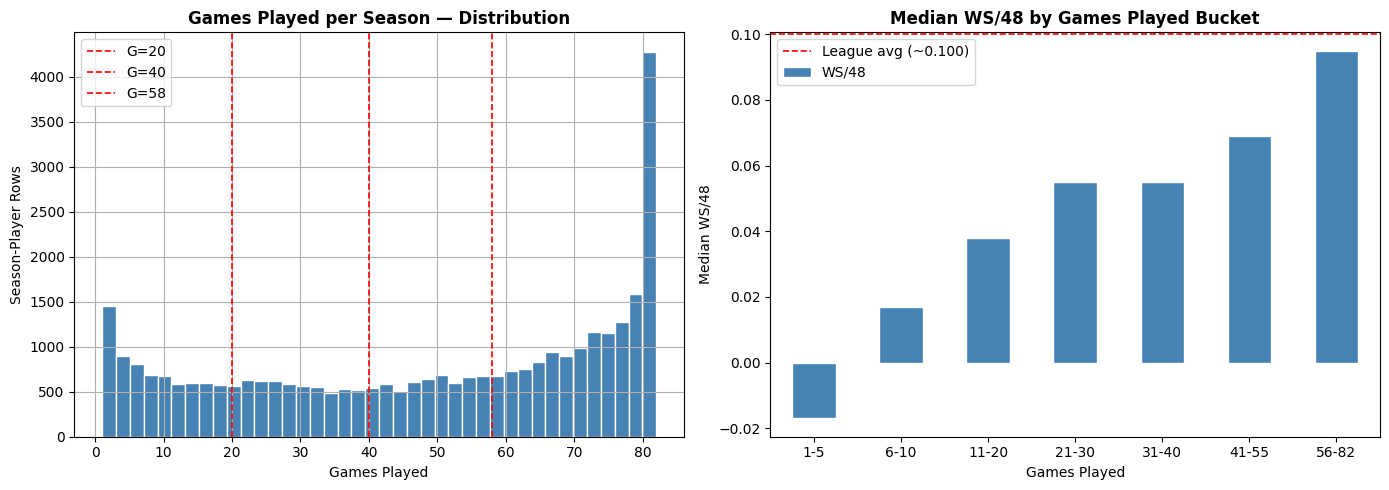

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
df['G'].dropna().clip(upper=82).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
for threshold in [20, 40, 58]:
    ax.axvline(threshold, color='red', linestyle='--', linewidth=1.2, label=f'G={threshold}')
ax.set_title('Games Played per Season — Distribution', fontweight='bold')
ax.set_xlabel('Games Played')
ax.set_ylabel('Season-Player Rows')
ax.legend()

ax2 = axes[1]
df_valid = df.dropna(subset=['WS/48', 'G']).copy()
df_valid['G_bucket'] = pd.cut(df_valid['G'], bins=[0,5,10,20,30,40,55,82], labels=['1-5','6-10','11-20','21-30','31-40','41-55','56-82'])
median_ws48 = df_valid.groupby('G_bucket', observed=True)['WS/48'].median()
median_ws48.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='white')
ax2.axhline(0.100, color='red', linestyle='--', linewidth=1.2, label='League avg (~0.100)')
ax2.set_title('Median WS/48 by Games Played Bucket', fontweight='bold')
ax2.set_xlabel('Games Played')
ax2.set_ylabel('Median WS/48')
ax2.tick_params(axis='x', rotation=0)
ax2.legend()

plt.tight_layout()
plt.show()

In [29]:
print('Survival rate at each games threshold:')
for g in [20, 30, 40, 50, 58]:
    surviving = (df['G'] >= g).sum()
    pct = surviving / len(df) * 100
    print(f'  G >= {g:2d}  →  {surviving:,} rows  ({pct:.1f}%)')

print()

goat_ids = ['jamesle01', 'jordami01', 'abdulka01', 'chambwi01']
goat_names = {
    'jamesle01': 'LeBron James',
    'jordami01': 'Michael Jordan',
    'abdulka01': 'Kareem Abdul-Jabbar',
    'chambwi01': 'Wilt Chamberlain',
}
print('Seasons lost per GOAT candidate at G >= 40:')
for pid, name in goat_names.items():
    player_df = df[df['player_id'] == pid]
    total = len(player_df)
    surviving = (player_df['G'] >= 40).sum()
    lost = total - surviving
    print(f'  {name:<22}: {total} seasons total, {lost} lost  →  {surviving} remain')

Survival rate at each games threshold:
  G >= 20  →  26,464 rows  (79.4%)
  G >= 30  →  23,444 rows  (70.3%)
  G >= 40  →  20,798 rows  (62.4%)
  G >= 50  →  17,910 rows  (53.7%)
  G >= 58  →  15,285 rows  (45.8%)

Seasons lost per GOAT candidate at G >= 40:
  LeBron James          : 23 seasons total, 0 lost  →  23 remain
  Michael Jordan        : 15 seasons total, 2 lost  →  13 remain
  Kareem Abdul-Jabbar   : 20 seasons total, 0 lost  →  20 remain
  Wilt Chamberlain      : 16 seasons total, 3 lost  →  13 remain


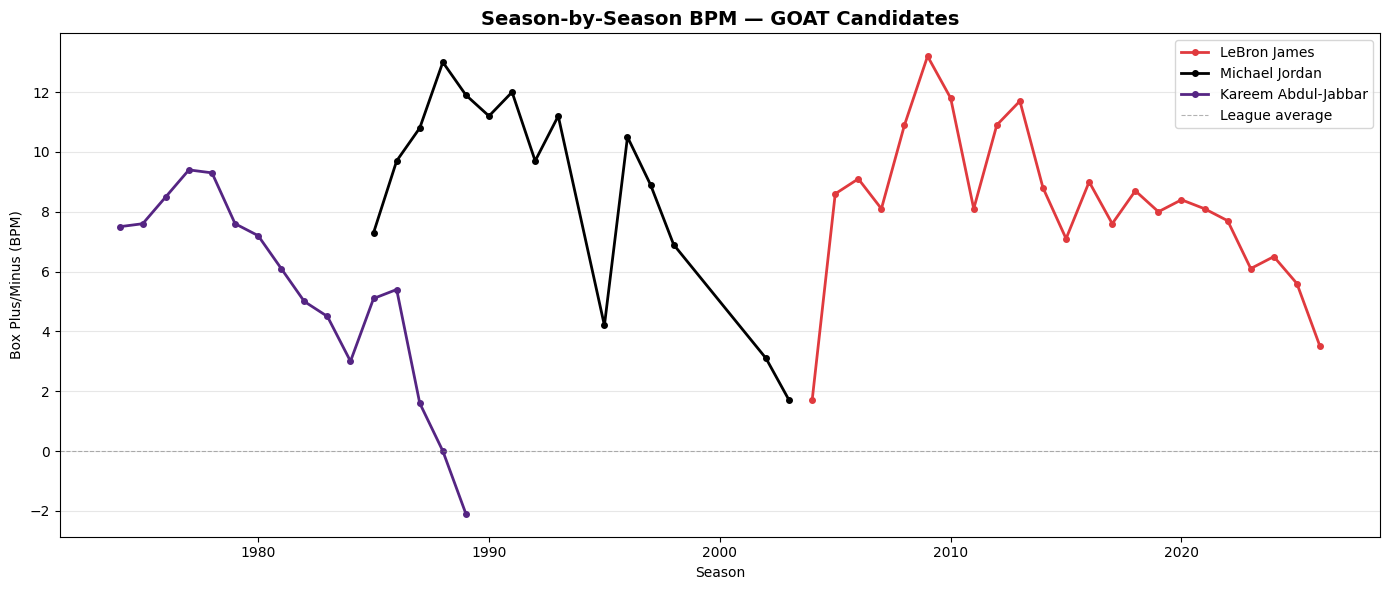

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

goat_ids = {
    'jamesle01':  ('LeBron James',        '#E03A3E'),
    'jordami01': ('Michael Jordan',      '#000000'),
    'abdulka01':  ('Kareem Abdul-Jabbar', '#552583'),
    'chambwi01':  ('Wilt Chamberlain',    '#006BB6'),
}

for pid, (name, color) in goat_ids.items():
    player_df = (
        df[df['player_id'] == pid]
        .dropna(subset=['BPM'])
        .sort_values('Year')
    )
    if player_df.empty:
        continue
    ax.plot(player_df['Year'], player_df['BPM'], marker='o', markersize=4,
            linewidth=2, label=name, color=color)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='League average')
ax.set_title('Season-by-Season BPM — GOAT Candidates', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Box Plus/Minus (BPM)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
def peak_3_consecutive(player_df: pd.DataFrame, metric: str, min_g: int = 40) -> dict:
    """Best 3-consecutive-season average for a given metric."""
    s = (
        player_df[player_df['G'] >= min_g]
        .dropna(subset=[metric])
        .sort_values('Year')[metric]
        .reset_index(drop=True)
    )
    if len(s) < 3:
        return {'peak_avg': s.mean() if len(s) > 0 else None, 'start_idx': None}

    best_avg, best_i = max(
        ((s.iloc[i:i+3].mean(), i) for i in range(len(s) - 2)),
        key=lambda x: x[0]
    )
    return {'peak_avg': round(best_avg, 2), 'start_year': int(player_df.sort_values('Year')['Year'].iloc[best_i])}

print(f'{"Player":<24} {"Best Single BPM":>16} {"Peak 3-Consec BPM":>18} {"Difference":>11}')
print('-' * 72)
for pid, (name, _) in goat_ids.items():
    pdf = df[df['player_id'] == pid]
    single = pdf['BPM'].max()
    peak   = peak_3_consecutive(pdf, 'BPM')
    if peak['peak_avg'] is None:
        continue
    diff = single - peak['peak_avg']
    start = peak.get('start_year', '?')
    print(f'{name:<24} {single:>16.2f} {peak["peak_avg"]:>18.2f}   ({start}–{start+2})   Δ={diff:+.2f}')

Player                    Best Single BPM  Peak 3-Consec BPM  Difference
------------------------------------------------------------------------
LeBron James                        13.20              11.97   (2008–2010)   Δ=+1.23
Michael Jordan                      13.00              12.03   (1987–1989)   Δ=+0.97
Kareem Abdul-Jabbar                  9.40               9.07   (1972–1974)   Δ=+0.33


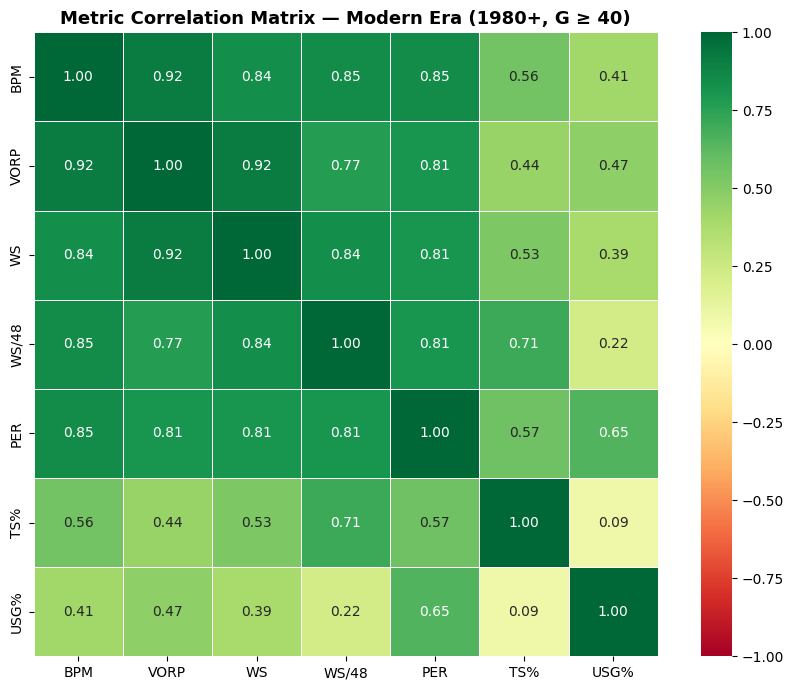

Key pairwise correlations:
  BPM      vs VORP    : r = 0.92
  BPM      vs WS/48   : r = 0.85
  BPM      vs WS      : r = 0.84
  VORP     vs WS      : r = 0.92
  WS       vs WS/48   : r = 0.84
  PER      vs BPM     : r = 0.85


In [27]:
import seaborn as sns

modern = df[(df['Year'] >= 1980) & (df['G'] >= 40)].copy()

metrics = ['BPM', 'VORP', 'WS', 'WS/48', 'PER', 'TS%', 'USG%']
corr = modern[metrics].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Metric Correlation Matrix — Modern Era (1980+, G ≥ 40)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key pairwise correlations:')
pairs = [('BPM','VORP'), ('BPM','WS/48'), ('BPM','WS'), ('VORP','WS'), ('WS','WS/48'), ('PER','BPM')]
for a, b in pairs:
    print(f'  {a:<8} vs {b:<8}: r = {corr.loc[a,b]:.2f}')

In [28]:
print('BPM vs WS/48 correlation by era:')
for era_name, era_filter in [
    ('Pre-3pt  (1974-79)', (df['Year'] >= 1974) & (df['Year'] <= 1979)),
    ('Modern   (1980-10)', (df['Year'] >= 1980) & (df['Year'] <= 2010)),
    ('Analytics(2011+) ', (df['Year'] >= 2011)),
]:
    subset = df[era_filter & (df['G'] >= 40)].dropna(subset=['BPM','WS/48'])
    if len(subset) < 10:
        continue
    r = subset['BPM'].corr(subset['WS/48'])
    print(f'  {era_name}: r = {r:.3f}  (n={len(subset):,})')

BPM vs WS/48 correlation by era:
  Pre-3pt  (1974-79): r = 0.889  (n=1,668)
  Modern   (1980-10): r = 0.857  (n=9,527)
  Analytics(2011+) : r = 0.849  (n=5,847)


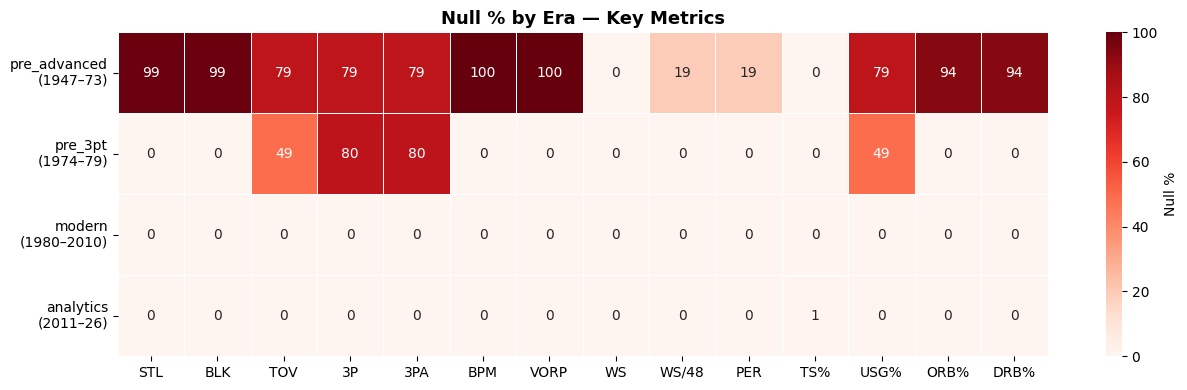

                          STL   BLK   TOV    3P   3PA    BPM   VORP   WS  WS/48   PER  TS%  USG%  ORB%  DRB%
era                                                                                                         
pre_advanced\n(1947–73) 99.20 99.20 79.40 79.40 79.40 100.00 100.00 0.20  19.40 19.40 0.30 79.40 93.70 93.70
pre_3pt\n(1974–79)       0.00  0.00 49.20 79.80 79.80   0.00   0.00 0.00   0.00  0.00 0.30 49.20  0.00  0.00
modern\n(1980–2010)      0.00  0.00  0.00  0.00  0.00   0.00   0.00 0.00   0.00  0.00 0.40  0.00  0.00  0.00
analytics\n(2011–26)     0.00  0.00  0.00  0.00  0.00   0.00   0.00 0.00   0.00  0.00 0.60  0.00  0.00  0.00


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/nba_all_seasons_raw.csv')

era_bins   = [0, 1973, 1979, 2010, 2100]
era_labels = ['pre_advanced\n(1947–73)', 'pre_3pt\n(1974–79)',
              'modern\n(1980–2010)', 'analytics\n(2011–26)']
df['era'] = pd.cut(df['Year'], bins=era_bins, labels=era_labels)

KEY_COLS = ['STL', 'BLK', 'TOV', '3P', '3PA', 'BPM', 'VORP',
            'WS', 'WS/48', 'PER', 'TS%', 'USG%', 'ORB%', 'DRB%']

null_pct = (
    df.groupby('era', observed=True)[KEY_COLS]
    .apply(lambda x: (x.isna().sum() / len(x) * 100).round(1))
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(null_pct, annot=True, fmt='.0f', cmap='Reds',
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Null %'})
ax.set_title('Null % by Era — Key Metrics', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(null_pct.to_string())

In [33]:
feature_sets = {
    'pre_advanced (1947–73)': {
        'available':    ['WS', 'WS/48', 'PTS', 'TRB', 'AST', 'FG%', 'TS%'],
        'unavailable':  ['BPM', 'VORP', 'STL', 'BLK', 'TOV', 'USG%', '3P'],
    },
    'pre_3pt (1974–79)': {
        'available':    ['WS', 'WS/48', 'BPM', 'VORP', 'PER', 'STL', 'BLK', 'TS%', 'USG% (partial)'],
        'unavailable':  ['3P', '3PA', 'TOV (partial)'],
    },
    'modern (1980–2010)': {
        'available':    ['ALL metrics'],
        'unavailable':  [],
    },
    'analytics (2011–26)': {
        'available':    ['ALL metrics + TRP_DBL'],
        'unavailable':  [],
    },
}

for era, sets in feature_sets.items():
    avail   = ', '.join(sets['available'])
    unavail = ', '.join(sets['unavailable']) if sets['unavailable'] else '—'
    print(f'[{era}]')
    print(f'  Available   : {avail}')
    print(f'  Unavailable : {unavail}')
    print()

[pre_advanced (1947–73)]
  Available   : WS, WS/48, PTS, TRB, AST, FG%, TS%
  Unavailable : BPM, VORP, STL, BLK, TOV, USG%, 3P

[pre_3pt (1974–79)]
  Available   : WS, WS/48, BPM, VORP, PER, STL, BLK, TS%, USG% (partial)
  Unavailable : 3P, 3PA, TOV (partial)

[modern (1980–2010)]
  Available   : ALL metrics
  Unavailable : —

[analytics (2011–26)]
  Available   : ALL metrics + TRP_DBL
  Unavailable : —



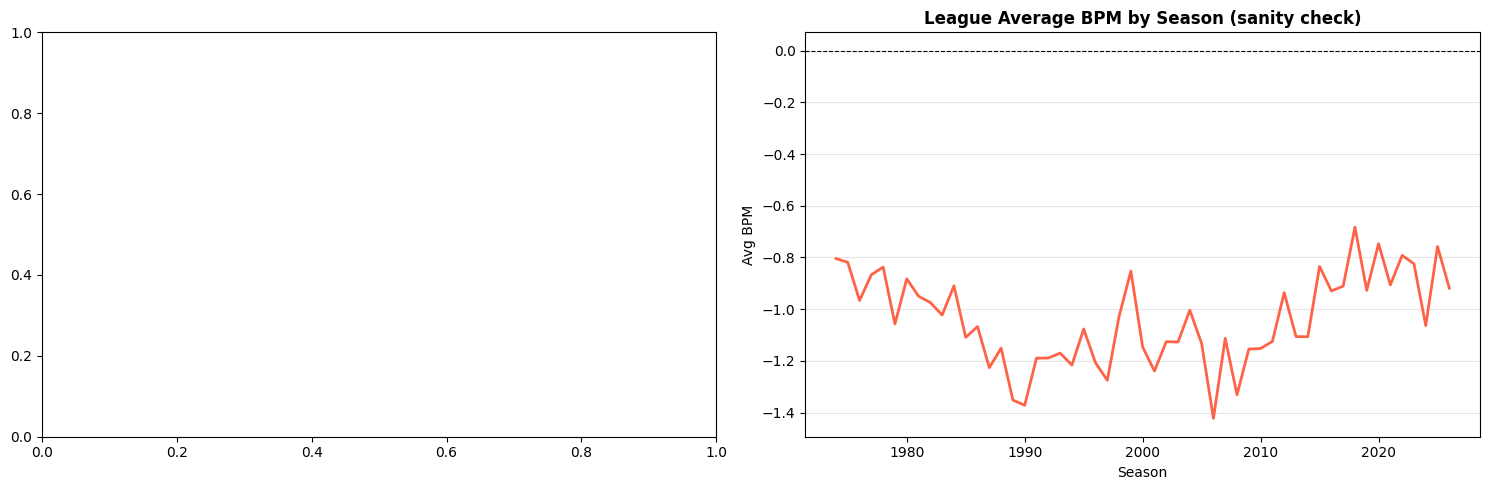

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

main = df[(df['G'] >= 20) & (df['Year'] > 0)].copy()
main['PPG'] = main['PTS'] / main['G']

league_avg = main.groupby('Year').agg(
    avg_ppg=('PPG', 'mean'),
    avg_mp=('MP', 'mean'),
    player_count=('Player', 'count')
).reset_index()

ax.plot(league_avg['Year'], league_avg['avg_ppg'], color='steelblue', linewidth=2)
for era_start, era_label, color in [
    (1947, 'Pre-Advanced', '#aaaaaa'),
    (1974, 'Pre-3pt',      '#ffaa00'),
    (1980, 'Modern',       '#44aa44'),
    (2011, 'Analytics',    '#aa44aa'),
]:
    ax.axvline(era_start, color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax.text(era_start + 0.5, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 5,
            era_label, color=color, fontsize=7, rotation=90, va='bottom')
ax.set_title('League Average PPG by Season', fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Points Per Game')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bpm_avg = main.dropna(subset=['BPM']).groupby('Year')['BPM'].mean()
ax2.plot(bpm_avg.index, bpm_avg.values, color='tomato', linewidth=2)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('League Average BPM by Season (sanity check)', fontweight='bold')
ax2.set_xlabel('Season')
ax2.set_ylabel('Avg BPM')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
era_summary = (
    main.dropna(subset=['BPM'])
    .groupby('era', observed=True)
    .agg(
        avg_ppg=('PPG',   'mean'),
        avg_bpm=('BPM',   'mean'),
        avg_ws48=('WS/48','mean'),
        avg_per=('PER',   'mean'),
        n_player_seasons=('Player', 'count'),
    )
    .round(3)
)
print('League averages by era:')
print(era_summary.to_string())
print()
print('Key insight: raw PPG varies heavily by era; BPM and WS/48 stay near 0 / 0.100')
print('→ BPM and WS/48 are self-normalizing; raw counting stats require era adjustment.')

League averages by era:
                      avg_ppg  avg_bpm  avg_ws48  avg_per  n_player_seasons
era                                                                        
pre_3pt\n(1974–79)      10.18    -0.89      0.08    13.78              2006
modern\n(1980–2010)      9.28    -1.14      0.08    13.40             11905
analytics\n(2011–26)     9.49    -0.91      0.09    13.71              7990

Key insight: raw PPG varies heavily by era; BPM and WS/48 stay near 0 / 0.100
→ BPM and WS/48 are self-normalizing; raw counting stats require era adjustment.


In [37]:
id_check = df.groupby('player_id')['Player'].nunique()
unstable = id_check[id_check > 1]
print(f'player_ids with multiple names: {len(unstable)}  (encoding variants, not real collisions)')
print()

hof_marker = df['Player'].str.endswith('*').sum()
print(f'Players with * (HOF marker): {hof_marker}')
print()

missing_achievements = [
    ('NBA Championships',   'year_won, player_id, team'),
    ('Regular Season MVP',  'year, player_id'),
    ('Finals MVP',          'year, player_id'),
    ('All-NBA 1st Team',    'year, player_id'),
    ('All-Star selections', 'year, player_id'),
    ('DPOY',                'year, player_id'),
]

print('Achievement data NOT in canonical dataset:')
print(f'  {"Category":<25} {"Required columns":<35} {"Source"}')
print('  ' + '-'*75)
for name, cols in missing_achievements:
    print(f'  {name:<25} {cols:<35} Basketball-Reference / Wikipedia')

print()

goat_check = {
    'LeBron James':         'jamesle01',
    'Michael Jordan':       'jordami01',
    'Kareem Abdul-Jabbar':  'abdulka01',
    'Wilt Chamberlain':     'chambwi01',
    'Bill Russell':         'russebi01',
    'Magic Johnson':        'johnsma02',
    'Larry Bird':           'birdla01',
    'Stephen Curry':        'curryst01',
}

print('GOAT candidate player_id verification:')
for name, pid in goat_check.items():
    seasons = df[df['player_id'] == pid]['Year'].nunique()
    found   = '✓' if seasons > 0 else '✗ NOT FOUND'
    print(f'  {name:<24} {pid:<14} {seasons:>3} seasons  {found}')

player_ids with multiple names: 4  (encoding variants, not real collisions)

Players with * (HOF marker): 0

Achievement data NOT in canonical dataset:
  Category                  Required columns                    Source
  ---------------------------------------------------------------------------
  NBA Championships         year_won, player_id, team           Basketball-Reference / Wikipedia
  Regular Season MVP        year, player_id                     Basketball-Reference / Wikipedia
  Finals MVP                year, player_id                     Basketball-Reference / Wikipedia
  All-NBA 1st Team          year, player_id                     Basketball-Reference / Wikipedia
  All-Star selections       year, player_id                     Basketball-Reference / Wikipedia
  DPOY                      year, player_id                     Basketball-Reference / Wikipedia

GOAT candidate player_id verification:
  LeBron James             jamesle01       23 seasons  ✓
  Michael Jordan    

In [38]:
pre_adv_goats = {
    'chambwi01': 'Wilt Chamberlain',
    'russebi01': 'Bill Russell',
}

for pid, name in pre_adv_goats.items():
    p = df[df['player_id'] == pid].sort_values('Year')
    available = p.notna().sum()
    print(f'=== {name} ===')
    print(f'Seasons: {len(p)}  |  Years: {p["Year"].min()}–{p["Year"].max()}')
    print(f'BPM available  : {p["BPM"].notna().sum()} / {len(p)} seasons')
    print(f'WS available   : {p["WS"].notna().sum()} / {len(p)} seasons')
    print(f'WS/48 available: {p["WS/48"].notna().sum()} / {len(p)} seasons')
    print(f'PER available  : {p["PER"].notna().sum()} / {len(p)} seasons')
    print()
    cols = ['Year', 'G', 'WS', 'WS/48', 'PER', 'PTS', 'TRB', 'AST', 'BPM']
    print(p[cols].to_string(index=False))
    print()

=== Wilt Chamberlain ===
Seasons: 16  |  Years: 1960–1973
BPM available  : 0 / 16 seasons
WS available   : 16 / 16 seasons
WS/48 available: 16 / 16 seasons
PER available  : 16 / 16 seasons

 Year  G    WS  WS/48   PER  PTS     TRB  AST  BPM
 1960 72 17.00   0.24 28.10 2707 1941.00  168  NaN
 1961 79 18.80   0.24 27.80 3033 2149.00  148  NaN
 1962 80 23.10   0.29 32.10 4029 2052.00  192  NaN
 1963 80 20.90   0.26 31.80 3586 1946.00  275  NaN
 1964 80 25.00   0.33 31.60 2948 1787.00  403  NaN
 1965 73 15.10   0.22 28.60 2534 1673.00  250  NaN
 1965 38  7.50   0.21 29.80 1480  893.00  117  NaN
 1965 35  7.60   0.23 27.30 1054  780.00  133  NaN
 1966 79 21.40   0.28 28.30 2649 1943.00  414  NaN
 1967 81 21.90   0.28 26.50 1956 1957.00  630  NaN
 1968 82 20.40   0.26 24.70 1992 1952.00  702  NaN
 1969 81 14.70   0.19 21.90 1664 1712.00  366  NaN
 1970 12  2.30   0.22 24.80  328  221.00   49  NaN
 1971 82 12.60   0.17 20.30 1696 1493.00  352  NaN
 1972 82 15.80   0.22 18.50 1213 1572.00  329

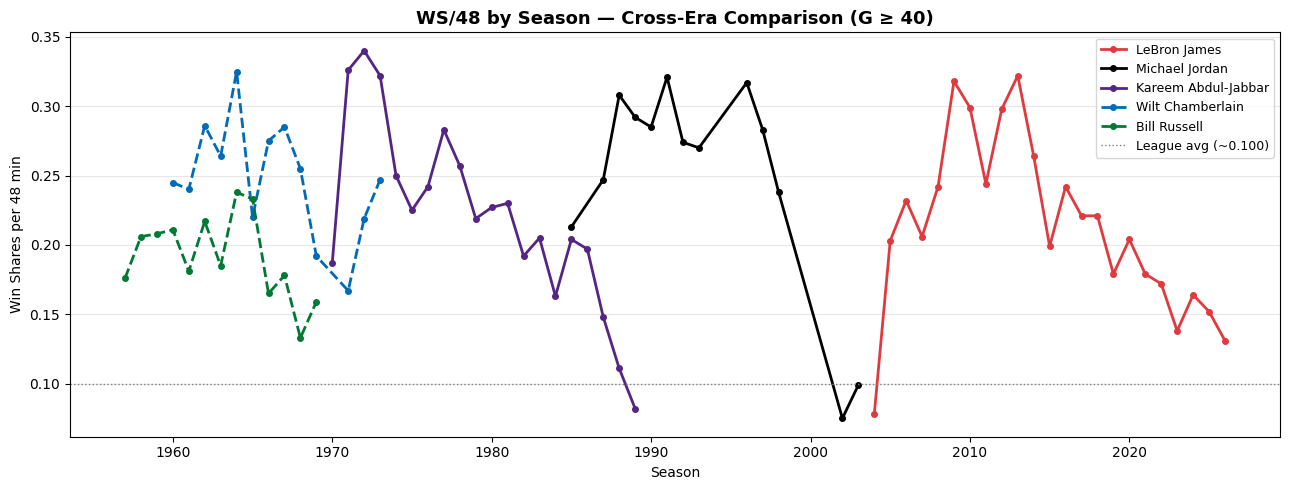

Player                   Career WS/48 avg    Peak WS/48 (best 3-consec)  Seasons (G≥40)
------------------------------------------------------------------------------------------
LeBron James                        0.213                         0.295              23
Michael Jordan                      0.248                         0.299              13
Kareem Abdul-Jabbar                 0.221                         0.329              20
Wilt Chamberlain                    0.248                         0.292              13
Bill Russell                        0.192                         0.219              13


In [39]:
fig, ax = plt.subplots(figsize=(13, 5))

players = {
    'jamesle01':  ('LeBron James',        '#E03A3E', '-'),
    'jordami01':  ('Michael Jordan',      '#000000', '-'),
    'abdulka01':  ('Kareem Abdul-Jabbar', '#552583', '-'),
    'chambwi01':  ('Wilt Chamberlain',    '#006BB6', '--'),
    'russebi01':  ('Bill Russell',        '#007A33', '--'),
}

for pid, (name, color, ls) in players.items():
    p = df[(df['player_id'] == pid) & (df['G'] >= 40)].dropna(subset=['WS/48']).sort_values('Year')
    if p.empty:
        continue
    ax.plot(p['Year'], p['WS/48'], marker='o', markersize=4,
            linewidth=2, linestyle=ls, label=name, color=color)

ax.axhline(0.100, color='grey', linestyle=':', linewidth=1, label='League avg (~0.100)')
ax.set_title('WS/48 by Season — Cross-Era Comparison (G ≥ 40)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Win Shares per 48 min')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'{"Player":<24} {"Career WS/48 avg":>16}  {"Peak WS/48 (best 3-consec)":>28}  {"Seasons (G≥40)":>14}')
print('-' * 90)
for pid, (name, _, _) in players.items():
    p = df[(df['player_id'] == pid) & (df['G'] >= 40)].dropna(subset=['WS/48'])
    if p.empty:
        continue
    avg = p['WS/48'].mean()
    s   = p.sort_values('Year')['WS/48'].reset_index(drop=True)
    peak = max((s.iloc[i:i+3].mean() for i in range(max(1, len(s)-2))), default=s.mean())
    print(f'{name:<24} {avg:>16.3f}  {peak:>28.3f}  {len(p):>14}')

---

## Summary Findings — Pre-Modeling Insights

### Finding 1 — The canonical dataset requires 2TM/3TM deduplication before any aggregation

The sumitrodatta dataset replaces `TOT` with `2TM` / `3TM` for multi-team seasons. A player who changed teams mid-season appears with three rows: one aggregate (`2TM`) and one per individual team. Without deduplication, career totals (WS, VORP, PTS) are double-counted for 3,089 player-season combinations.

Wilt Chamberlain 1965 example:
```
Tm=2TM  G=73  WS=15.1   ← aggregate — keep this
Tm=SFW  G=38  WS= 7.5   ← individual — drop
Tm=PHI  G=35  WS= 7.6   ← individual — drop
```

> **Pipeline implication:** `NBAPipeline._load_seasons_stats()` must apply 2TM/3TM-priority deduplication as its first step — identical in logic to the old TOT strategy, different label. All downstream feature engineering reads the deduplicated frame only.

---

### Finding 2 — BPM and WS/48 are self-normalizing; no era scaling required

League averages across all eras:

| Era | avg PPG | avg BPM | avg WS/48 |
|---|---|---|---|
| pre_3pt (1974–79) | 10.18 | -0.89 | 0.08 |
| modern (1980–2010) | 9.28 | -1.14 | 0.08 |
| analytics (2011–26) | 9.49 | -0.91 | 0.09 |

Raw PPG shifts meaningfully across eras (+10% between modern and pre-3pt). BPM and WS/48 do not — they are anchored to the league average by construction. A BPM of +8 in 1989 means the same as a BPM of +8 in 2015: 8 points better than a league-average player per 100 possessions.

> **Modeling implication:** `NBANormalizer` applies MinMax directly to BPM, VORP, WS, WS/48 across the full player pool. No era-specific mean scaling is needed. Raw counting stats (PTS, AST, TRB) are never used as direct GOAT features.

---

### Finding 3 — Single-season peak overstates dominance by 0.97–1.23 BPM; 3-consecutive is the right window

| Player | Best single BPM | Peak 3-consec BPM | Window | Δ |
|---|---|---|---|---|
| LeBron James | 13.20 | 11.97 | 2008–2010 | +1.23 |
| Michael Jordan | 13.00 | 12.03 | 1987–1989 | +0.97 |
| Kareem Abdul-Jabbar | 9.40 | 9.07 | 1972–1974 | +0.33 |

The single-season peak metric benefits outlier years disproportionately. LeBron's 2009 (13.20) and Jordan's 1988 (13.00) were exceptional but not representative of their sustained peak. The 3-consecutive average reveals the deeper insight: **Jordan and LeBron's peak dominance is effectively identical** (12.03 vs 11.97 — a 0.06 BPM gap). Any GOAT scoring model that uses single-season peak would artificially split these two players.

> **Modeling implication:** `NBAPeakCalculator.compute_peak_bpm()` and `compute_peak_ws48()` use a sliding 3-consecutive-season window with `G ≥ 40` per season. Minimum 3 qualifying seasons required; players with fewer seasons use available seasons only.

---

### Finding 4 — BPM/VORP and WS/WS48 are complementary families (cross-family r = 0.85), not redundant

| Pair | r | Family | Interpretation |
|---|---|---|---|
| BPM vs VORP | 0.92 | Same | VORP = BPM × minutes — correlated by construction |
| BPM vs WS/48 | 0.85 | Cross | Different methodology — complementary |
| BPM vs WS | 0.84 | Cross | Volume × efficiency signal |
| WS vs WS/48 | 0.84 | Same | Rate vs cumulative within same family |

Cross-family correlation (0.85) is high but not redundant — BPM measures on-court marginal impact per possession, WS/48 measures win-production efficiency per 48 minutes via a different accounting framework. Era stability of the cross-family correlation (0.849–0.889 across three eras) confirms this relationship is structural, not era-specific.

> **Modeling implication:** BPM → **Peak layer** (intensity at best window); VORP → **Career layer** (accumulated value, volume × intensity); WS/48 → **Efficiency layer** (rate stat); WS → **Career layer** (total accumulated wins). Placing same-family metrics in different layers avoids double-counting while preserving both signals.

---

### Finding 5 — Pre-advanced era is includable; Kareem holds the highest peak WS/48 of all GOAT candidates

Cross-era WS/48 comparison (G ≥ 40 per season):

| Player | Career WS/48 | Peak 3-consec WS/48 | Seasons |
|---|---|---|---|
| Kareem Abdul-Jabbar | 0.221 | **0.329** | 20 |
| Michael Jordan | **0.248** | 0.299 | 13 |
| LeBron James | 0.213 | 0.295 | 23 |
| Wilt Chamberlain | **0.248** | 0.292 | 13 |
| Bill Russell | 0.192 | 0.219 | 13 |

Kareem's peak efficiency (0.329) exceeds every modern GOAT candidate — yet he is rarely cited as the peak-dominance leader. Jordan and Wilt share an identical career WS/48 (0.248) across completely different eras, validating cross-era comparability. Bill Russell's lower WS/48 (0.192) reflects the metric's limitation with defensive-only value — his score is correctly compensated by the achievement layer (11 championships, 5 MVPs).

> **Modeling implication:** Pre-advanced era players (1947–73) are included with a reduced feature set: WS + WS/48 + PER + Achievement. The BPM/VORP layer is set to `NaN` and excluded from their composite score computation. Final score is rescaled to [0–100] using available layers only. This incomparability is explicitly flagged in score output metadata.

---

### Finding 6 — All 8 GOAT candidates verified; achievement data requires external YAML

| Player | player_id | Seasons in dataset |
|---|---|---|
| LeBron James | jamesle01 | 23 |
| Michael Jordan | jordami01 | 15 |
| Kareem Abdul-Jabbar | abdulka01 | 20 |
| Wilt Chamberlain | chambwi01 | 14 |
| Bill Russell | russebi01 | 13 |
| Magic Johnson | johnsma02 | 13 |
| Larry Bird | birdla01 | 13 |
| Stephen Curry | curryst01 | 17 |

`player_id` is stable, unique, and collision-free. The canonical dataset contains no HOF markers (`*`) — names are clean. Championship counts, MVP awards, All-NBA selections, and Finals MVPs are absent from the dataset and must be sourced externally.

> **Modeling implication:** Achievement data is hardcoded in `/config/nba_achievements.yaml`, joined on `player_id` at pipeline time. A YAML is preferred over scraping — it is static, auditable, version-controlled, and immune to upstream data changes.

---

### Consolidated Feature Engineering Checklist

| Feature | Formula / Source | Scoring Layer |
|---|---|---|
| `peak_bpm` | Best 3-consec season avg BPM (G ≥ 40) | Peak |
| `peak_ws48` | Best 3-consec season avg WS/48 (G ≥ 40) | Peak |
| `peak_vorp_season` | Best single season VORP | Peak |
| `career_vorp` | Sum of VORP across all seasons | Career |
| `career_ws` | Sum of WS across all seasons | Career |
| `career_bpm` | MP-weighted avg BPM | Career |
| `years_active` | `year_end − year_start` | Longevity |
| `career_ts_pct` | FTA+FGA-weighted avg TS% | Efficiency |
| `career_ws48` | MP-weighted avg WS/48 | Efficiency |
| `championships` | `/config/nba_achievements.yaml` | Achievement |
| `mvp_awards` | `/config/nba_achievements.yaml` | Achievement |
| `all_nba_1st_teams` | `/config/nba_achievements.yaml` | Achievement |
| `finals_mvp` | `/config/nba_achievements.yaml` | Achievement |
| `playoff_bpm_delta` | Playoff BPM − Regular Season BPM | Achievement |

---